<a href="https://colab.research.google.com/github/isingizwetuyizerejeandelapaix-blip/Web_Ass_2_group_2_II_B/blob/main/aiml03_module3_assignment_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# SAVE THIS FILE TO YOUR GOOGLE DRIVE (File -> Save a copy in Drive)
# Then, run this initializing cell on the newly opened COPY and begin your work

# Install otter grader package
!pip install otter-grader==6.1.6

# Import libraries used to install and run tests locally
import zipfile
import urllib.request
import os
import otter

# Download data for this assignment from Gist
url1 = "https://gist.githubusercontent.com/CMU-Africa/4444f62faf270664940ae12417aa5e06/raw/mod3_data.zip"
urllib.request.urlretrieve(url1, "mod3_data.zip")
with zipfile.ZipFile("mod3_data.zip", 'r') as zip_ref:
    zip_ref.extractall()

# Download tests for this assignment from Gist
url2 = "https://gist.githubusercontent.com/CMU-Africa/4444f62faf270664940ae12417aa5e06/raw/tests.zip"
urllib.request.urlretrieve(url2, "tests.zip")
with zipfile.ZipFile("tests.zip", 'r') as zip_ref:
    zip_ref.extractall()


# Initialize Otter
grader = otter.Notebook()  # Assigns it this notebook
print("Setup complete!")

Setup complete!


# Question 1
Based on the code from Module 3, refactor the code to read in data from a maize_yield CSV file into a dataframe, using the functions you will write to calculate the regression statistics and plot the best-fit line and scatter points.

In order to complete this program, write the following 2 functions:

1. **calc_stats(df)**: performs the statistics on the data frame and returns 2 values:
    * the r-value
    * the list of predicted maize yields
  
  * Note that **calc_stats()** should calculate the slope, r_value, p_value, and std_err similar to how it was calculated in L11.

2. **plot_data(x, y, r_val, prediction)**: creates the plot that was coded in Module 3.

---------- Algorithm for your main code ----------

1. Your program should read in the data from **maize_yield1.csv**, call **calc_stats()** and plot it with a call to **plot_data()**. IMPORTANT: store the read-in data in a variable called **df1**.

2. It should then read in the data from **maize_yield2.csv** and plot it. IMPORTANT: store the read-in data in a variable called **df2**.

3. You should note that **maize_yield2.csv** has values that are outliers from our simple correlation of a straight line. A common way to deal with data like this would be to perform a more complex statistical analysis, but for this assignment you should "clean" the data (IMPORTANT: store the cleaned-up data in a variable called **filtered_data**).
4. To clean it, you will remove the data where:

    * the rainfall is below 400
    * the rainfall is 700 or above

5. After removing these values, re-plot the data.
  * Note that you can tell if you got it right if your last graph matches the first one.



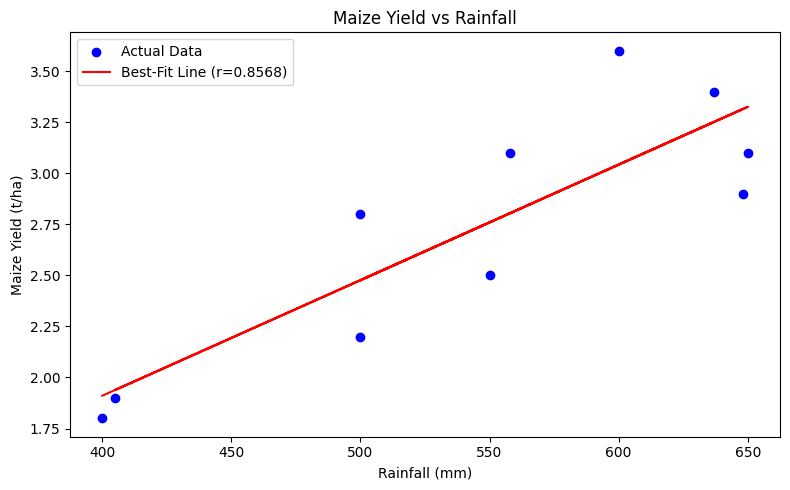

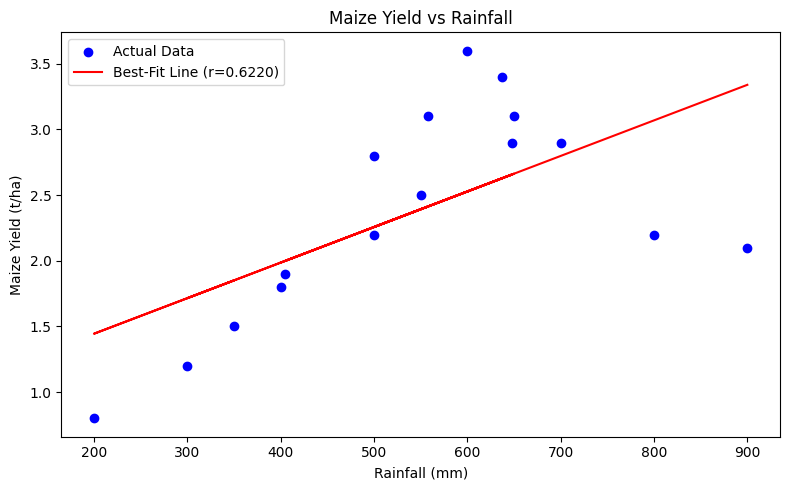

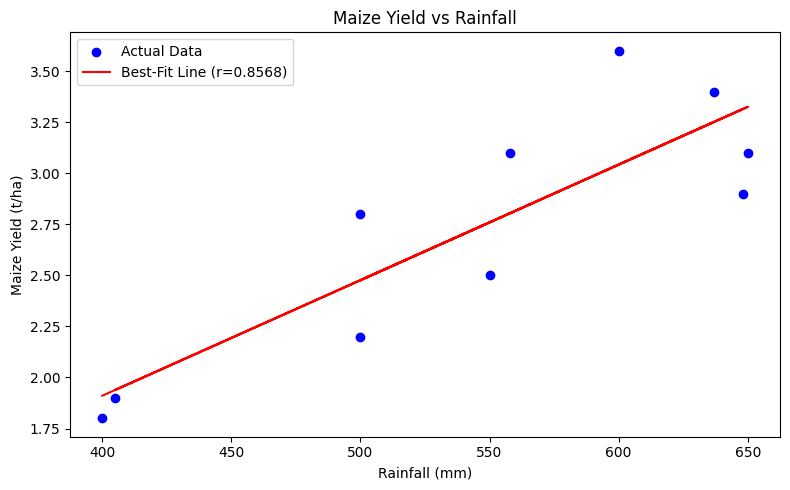

In [14]:
# Q1 Solution

import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd

def calc_stats(df):
    slope, intercept, r_value, p_value, std_err = linregress(df['Rainfall_mm'], df['Maize_Yield_t_ha'])
    predicted_yield = slope * df['Rainfall_mm'] + intercept
    return r_value, predicted_yield

def plot_data(x, y, r_val, prediction):
    # Plotting
    plt.figure(figsize=(8, 5))

    # Scatter plot (actual data)
    plt.scatter(x, y, color='blue', label='Actual Data')

    # Regression line (predicted yield)
    plt.plot(x, prediction, color='red', label=f'Best-Fit Line (r={r_val:.4f})')

    # Labels and layout
    plt.xlabel('Rainfall (mm)')
    plt.ylabel('Maize Yield (t/ha)')
    plt.title('Maize Yield vs Rainfall')
    plt.legend()
    plt.tight_layout()
    plt.show()


#------ Main Code ------

def calculate_all_stats(file1, file2):
    # Read data from maize_yield1.csv, put it in a dataframe named df1
    df1 = pd.read_csv(file1)

    # Calculate stats for df1
    r_value1, predicted_yield1 = calc_stats(df1)

    # Read data from maize_yield2.csv, put it in a dataframe named df2
    df2 = pd.read_csv(file2)

    # Calculate stats for df2
    r_value2, predicted_yield2 = calc_stats(df2)

    # filter out rainfall < 400 and >= 700, put it in a dataframe named filtered_data
    filtered_data = df2[(df2['Rainfall_mm'] >= 400) & (df2['Rainfall_mm'] < 700)].reset_index(drop=True)

    # Calculate stats for filtered_data
    r_value3, predicted_yield3 = calc_stats(filtered_data)

    return df1, df2, filtered_data, r_value1, r_value2, r_value3, predicted_yield1, predicted_yield2, predicted_yield3


# Unpack all return values
df1, df2, filtered_data, r_value1, r_value2, r_value3, \
    predicted_yield1, predicted_yield2, predicted_yield3 = \
    calculate_all_stats('maize_yield1.csv', 'maize_yield2.csv')

# Plot all three
plot_data(df1['Rainfall_mm'], df1['Maize_Yield_t_ha'], r_value1, predicted_yield1)
plot_data(df2['Rainfall_mm'], df2['Maize_Yield_t_ha'], r_value2, predicted_yield2)
plot_data(filtered_data['Rainfall_mm'], filtered_data['Maize_Yield_t_ha'], r_value3, predicted_yield3)


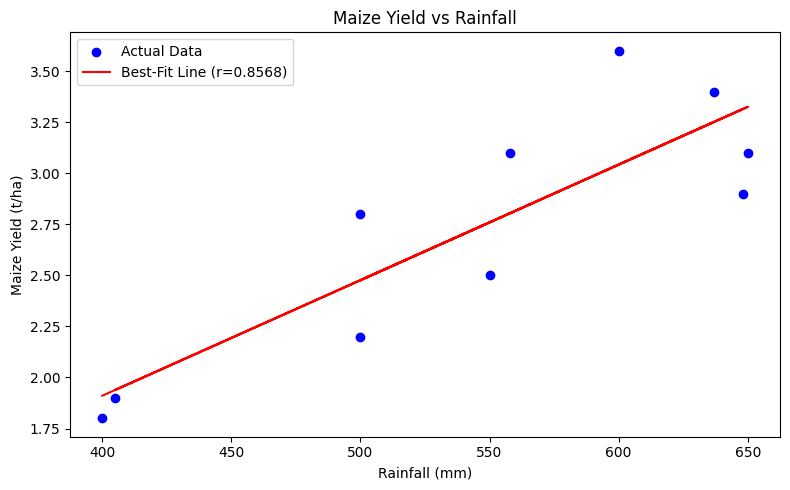

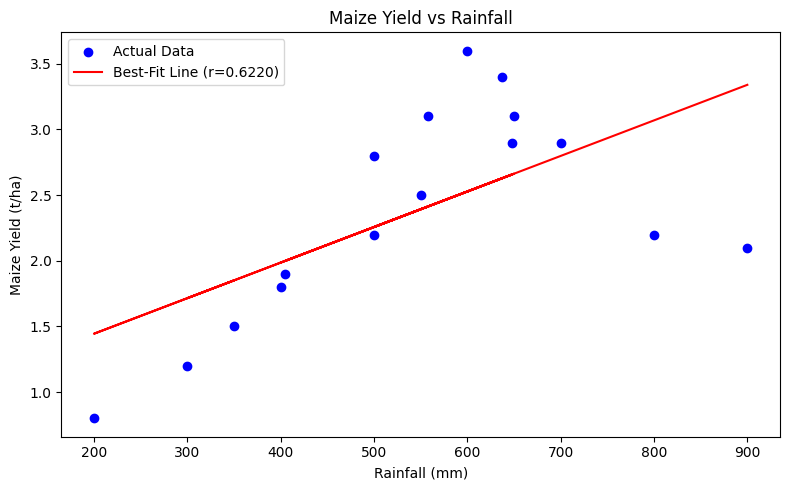

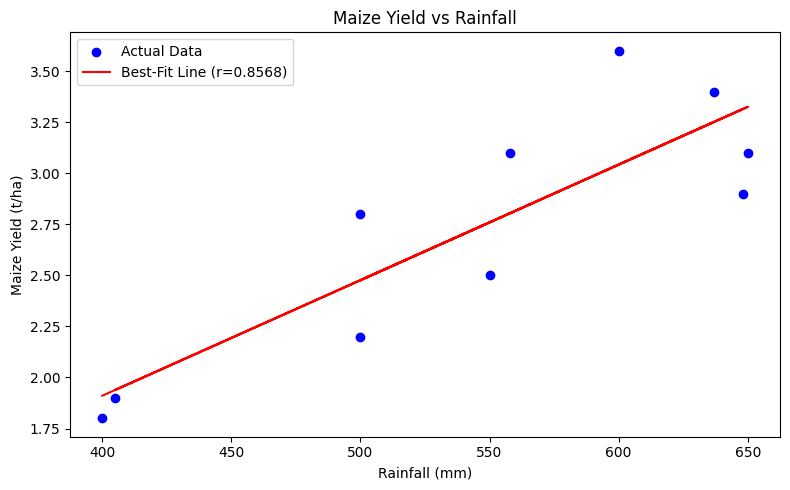

In [15]:
 # Calculate all stats by calling the function calculate_all_stats
df1, df2, filtered_data, r_value1, r_value2, r_value3, predicted_yield1, predicted_yield2, predicted_yield3 = calculate_all_stats('maize_yield1.csv', 'maize_yield2.csv')

# Plot the stats for df1
plot_data(df1['Rainfall_mm'], df1['Maize_Yield_t_ha'], r_value1, predicted_yield1)

# Plot the stats for df2
plot_data(df2['Rainfall_mm'], df2['Maize_Yield_t_ha'], r_value2, predicted_yield2)

# Plot the stats for filtered_data
plot_data(filtered_data['Rainfall_mm'], filtered_data['Maize_Yield_t_ha'], r_value3, predicted_yield3)

## Important: Submit the files generated below along with this notebook in a zip file to Gradescope

In [16]:
import json
#### RUN THIS CELL TO SAVE DATAFRAMES AND VARIABLES NEEDED FOR AUTOGRADER: DO NOT CHANGE ####
df1.to_csv('df1.csv', index=False)
df2.to_csv('df2.csv', index=False)
filtered_data.to_csv('filtered_data.csv', index=False)
# Create a dictionary to hold all the variables
analysis_data = {
    'r_value1': float(r_value1),
    'r_value2': float(r_value2),
    'r_value3': float(r_value3),
    'predicted_yield1': [float(y) for y in predicted_yield1],
    'predicted_yield2': [float(y) for y in predicted_yield2],
    'predicted_yield3': [float(y) for y in predicted_yield3]
}

# Save the dictionary to a JSON file
with open('analysis_results.json', 'w') as f:
    json.dump(analysis_data, f, indent=4)

print("Dataframes and variables saved successfully.")

Dataframes and variables saved successfully.


In [17]:
import otter
grader = otter.Notebook()
grader.check("q1")

q1 results: All test cases passed!

# Question 2
Use your your code from Q1 as guide, update it to plot based on age brackets instead of gender.

As you work through the Code Block, keep the prints and make sure to use the specified variable names.




The resulting graph should look like this:

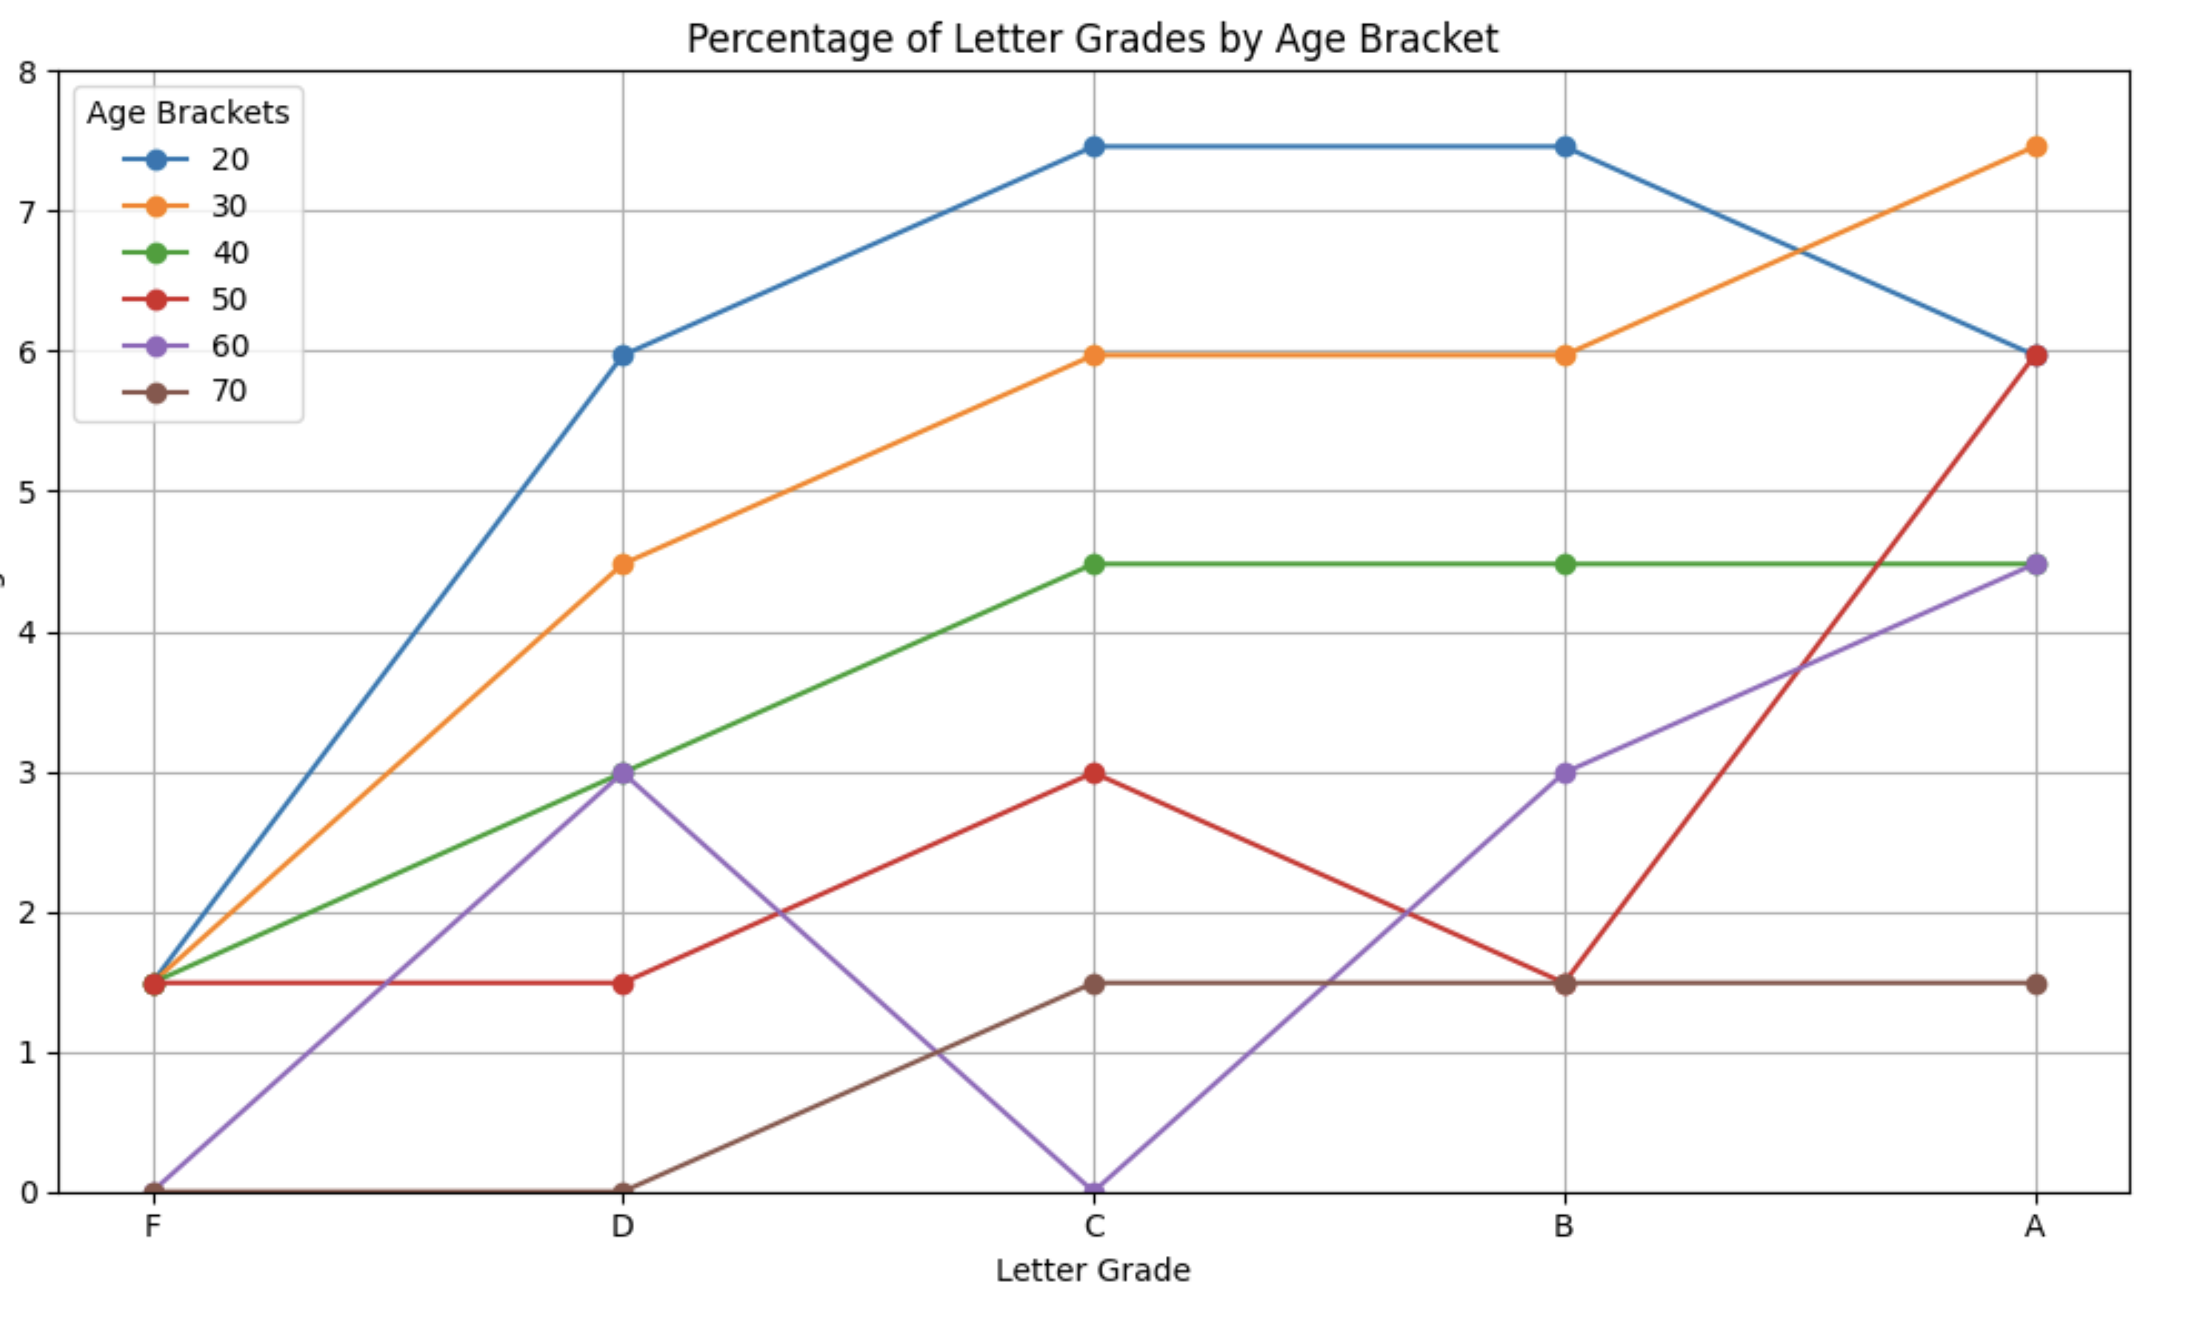


In [18]:
# Q2 Solution

import pandas as pd
import math
import matplotlib.pyplot as plt

def calculate_age_brackets(file):
    # Read the data from the scores_all_more.xlsx into a dataframe named df
    df = pd.read_excel(file)

    # Convert Age safely, drop rows where Age is invalid
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df = df.dropna(subset=['Age'])
    df['Age'] = df['Age'].astype(int)

    # only keep data where the age is 20 and over and under 80
    df = df[(df['Age'] >= 20) & (df['Age'] < 80)]

    # drop rows with missing Score
    df = df.dropna(subset=['Score'])

    determine_age_decade = lambda x: (x // 10 * 10)

    # Create a new column called 'Age Bracket' that uses the lambda above to set the age decades
    df['Age Bracket'] = df['Age'].apply(determine_age_decade)

    # Add the Letter Grade buckets to df
    df['Letter Grade'] = pd.cut(
        df['Score'],
        bins=[0, 60, 70, 80, 90, 100],
        labels=['F', 'D', 'C', 'B', 'A']
    )

    # group the data and create the Count - use grade_counts to store the result
    grade_data = df.groupby(['Age Bracket', 'Letter Grade']).size()
    grade_counts = grade_data.reset_index(name='Count')

    # Count total per Age Bracket, sum for total counts
    counts = grade_counts.groupby('Age Bracket')['Count'].sum()
    count_all = grade_counts['Count'].sum()

    # Add Percentage All column
    grade_counts['Percentage All'] = (
        grade_counts['Count'] / grade_counts['Count'].sum() * 100
    )

    # Get unique Age Bracket values, stores them in a variable named values
    values = sorted(df['Age Bracket'].unique())

    # calculate max_percent and ylimit
    max_percent = round(grade_counts['Percentage All'].max(), 2)
    ylimit = math.ceil(max_percent)

    return df, grade_counts, count_all, values, max_percent, ylimit

Max percentage is: 7.46 so ylimit is: 8


/tmp/ipykernel_2154/822527731.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_data = df.groupby(['Age Bracket', 'Letter Grade']).size()


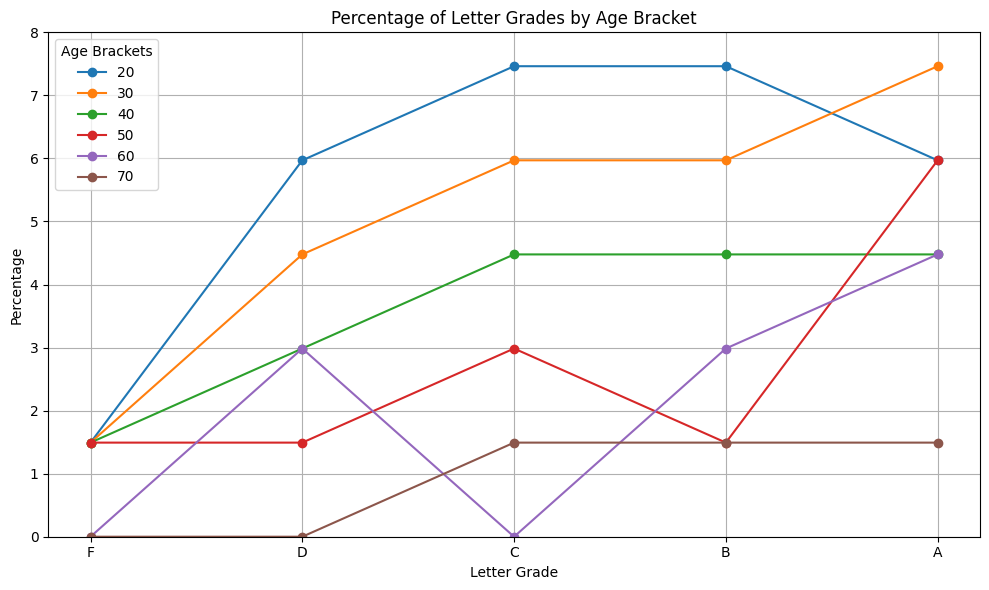

In [19]:
# Run the function first
df, grade_counts, count_all, values, max_percent, ylimit = calculate_age_brackets(
    'scores_all_more.xlsx'
)

# ----- Plotting code
# Code to graph Total percentages by age bracket for each letter grade

plt.figure(figsize=(10, 6))

# Plot each Age Bracket as a separate line
for var in values:
    data_for_var = grade_counts[
        grade_counts['Age Bracket'] == var
    ]
    plt.plot(
        data_for_var['Letter Grade'],
        data_for_var['Percentage All'],
        marker='o',
        label=str(var)
    )

# Customize
plt.title('Percentage of Letter Grades by Age Bracket')
plt.ylabel('Percentage')
plt.xlabel('Letter Grade')

print(f"Max percentage is: {max_percent} so ylimit is: {ylimit}")

plt.ylim(0, ylimit)
plt.legend(title='Age Brackets')
plt.grid(True)
plt.tight_layout()
plt.show()


Max percentage is: 7.46 so ylimit is: 8


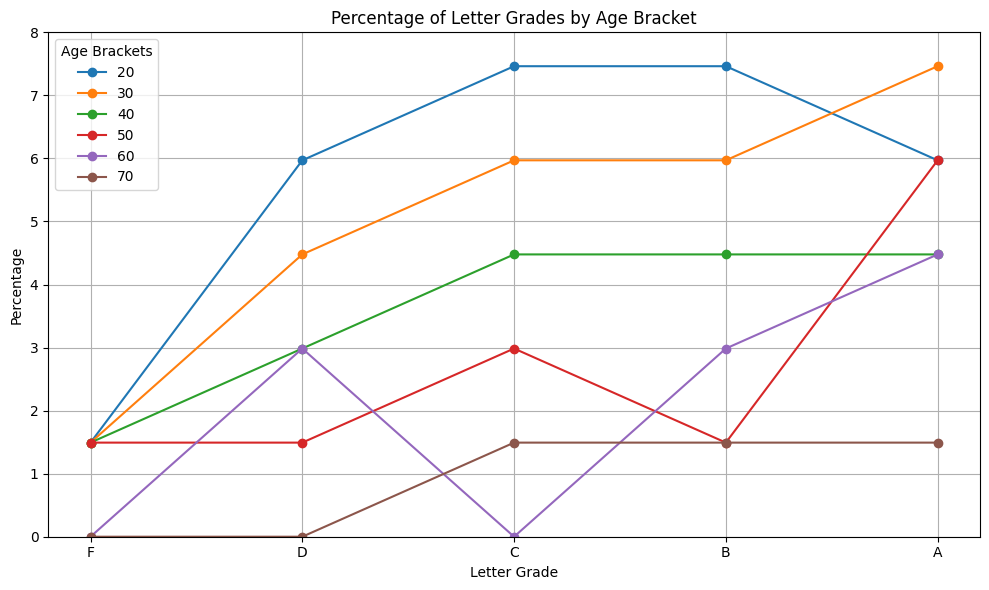

In [20]:

# ----- Plotting code
# Code to graph Total percentages by gender for each letter grade
plt.figure(figsize=(10, 6))

# Plot each Age Bracket as a separate line
# Create a loop that handles each Age Bracket separately so we can plot them separately
for var in values:
    data_for_var = grade_counts[grade_counts['Age Bracket'] == var]
    plt.plot(
        data_for_var['Letter Grade'],
        data_for_var['Percentage All'],
        marker='o',
        label=str(var)
    )

# Customize
plt.title(f'Percentage of Letter Grades by Age Bracket')
plt.ylabel('Percentage')
plt.xlabel('Letter Grade')

print(f"Max percentage is: {max_percent} so ylimit is: {ylimit}")

plt.ylim(0, ylimit)
plt.legend(title='Age Brackets')
plt.grid(True)
plt.tight_layout()
plt.show()

## Important: Submit the files generated below along with this notebook in a zip file to Gradescope

In [21]:
#### RUN THIS CELL TO SAVE DATAFRAMES AND VARIABLES NEEDED FOR AUTOGRADER: DO NOT CHANGE ####
import json

df.to_csv('df.csv', index=False)

data_to_save = {
    'max_percent': float(max_percent),
    'ylimit': float(ylimit),
    'count_all': float(count_all)
}

# Save the dictionary to a JSON file
with open('analysis_results_q2.json', 'w') as f:
    json.dump(data_to_save, f, indent=4)

print("DataFrame 'df' and variables saved successfully.")

DataFrame 'df' and variables saved successfully.


In [22]:
grader.check("q2")

q2 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [23]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

In [24]:
from google.colab import files
files.download('df1.csv')
files.download('df2.csv')
files.download('filtered_data.csv')
files.download('analysis_results.json')
files.download('df.csv')
files.download('analysis_results_q2.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>